In [1]:
import os
from pathlib import Path
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)


root_dir = "data"  
img_shape = (112, 92) 
n_subjects = 40
images_per_subject = 10

def load_karo(root_dir):
    root = Path(root_dir)
    X = []
    y = []
    
    for i in range(1, n_subjects + 1):
        folder = root / f's{i}'
        files = sorted(folder.glob('*'))
        for fp in files:
            # pil requires height, width so indexes swapped
            img = Image.open(fp).convert('L').resize((img_shape[1], img_shape[0]))
            arr = np.asarray(img, dtype=np.float32)
            # 2D to 1D flatten
            X.append(arr.ravel())
            y.append(i - 1)

    return np.array(X), np.array(y)

X, y = load_karo(root_dir)
print('Loaded', X.shape, 'labels unique:', np.unique(y).size)

Loaded (400, 10304) labels unique: 40


L = gray scale and loaded 400 samples so all correctly loaded

In [2]:
print(X.shape, y.shape)

(400, 10304) (400,)


X.shape should be (400, 10304) and y.shape (400,) for the full ORL dataset. deviation = failed load

In [3]:
from collections import Counter

unique_labels = np.unique(y)
print('Subjects found:', unique_labels.size)

train_idx = []
test_idx = []
for lbl in unique_labels:
    idxs = np.where(y == lbl)[0]
    if len(idxs) >= 10:
        # pehla 7 as train pachina as test as me joyu ke 10-10 aj che 
        np.random.shuffle(idxs)
        train_idx.extend(idxs[:7].tolist())
        test_idx.extend(idxs[7:].tolist())

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

mean_face = X_train.mean(axis=0)
# population std. dev. for each pixel
std_face = X_train.std(axis=0, ddof=0)
# div by 0 error mate
std_face[std_face == 0] = 1.0

X_train_std = (X_train - mean_face) / std_face
X_test_std = (X_test - mean_face) / std_face

print('Train/Test shapes:', X_train.shape, X_test.shape)


Subjects found: 40
Train/Test shapes: (280, 10304) (120, 10304)


manual train-test split, not using scikit learn
so train = 280, test = 120 

In [4]:
def pca(X, n_components):
    # covariance matrix
    mat = np.cov(X, rowvar=False)
    # eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(mat)
    # sort by largest eigenvalues
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]
    # select a subset of the eigenvectors, baddhi rows but only this many components
    components = eigenvectors[:, :n_components]
    return components, eigenvalues[:n_components]

components_train, eigenvalues_train = pca(X_train_std, 3)
components_test, eigenvalues_test = pca(X_test_std, 3)
print('PCA done, components shape:', components_train.shape)
print('Eigenvalues:', eigenvalues_train)

PCA done, components shape: (10304, 3)
Eigenvalues: [1676.8982465  1303.37285237  837.4023035 ]


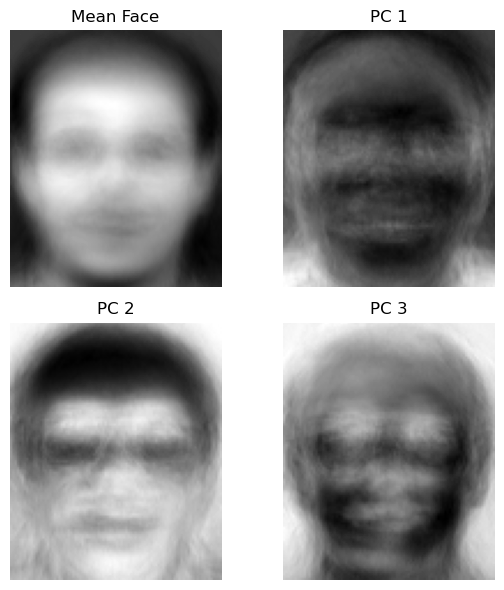

In [ ]:
import matplotlib.pyplot as plt

h, w = img_shape[0], img_shape[1] 

mean_face = X_train.mean(axis=0)
eigenfaces = components_train[:, :3].T  # shape (3, n_features)

plt.figure(figsize=(6,6))

plt.subplot(2, 2, 1)
plt.imshow(mean_face.reshape(h, w), cmap='gray')
plt.title("Mean Face")
plt.axis("off")

for i in range(3):
    plt.subplot(2, 2, i+2)   
    plt.imshow(eigenfaces[i].reshape(h, w), cmap='gray')
    plt.title(f"PC {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


Proper contrast indicates PCA worked; noisy or unstructured patterns would suggest preprocessing issues.

k=5, MSE=805.8803
k=10, MSE=619.4749
k=10, MSE=619.4749
k=20, MSE=457.3745
k=20, MSE=457.3745
k=30, MSE=368.7888
k=30, MSE=368.7888
k=50, MSE=265.1999
k=50, MSE=265.1999


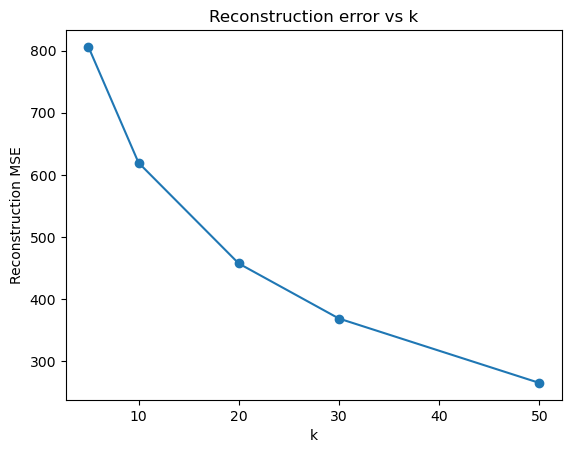

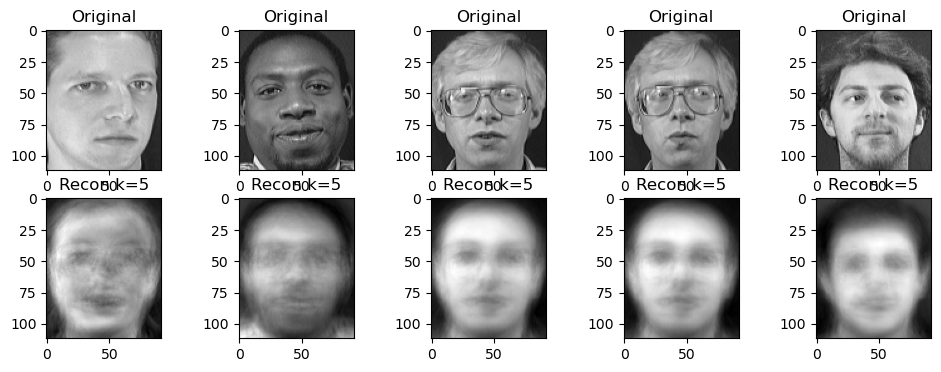

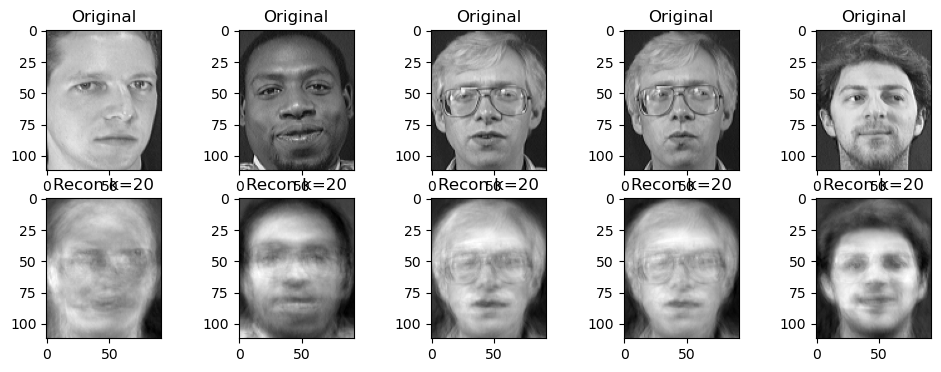

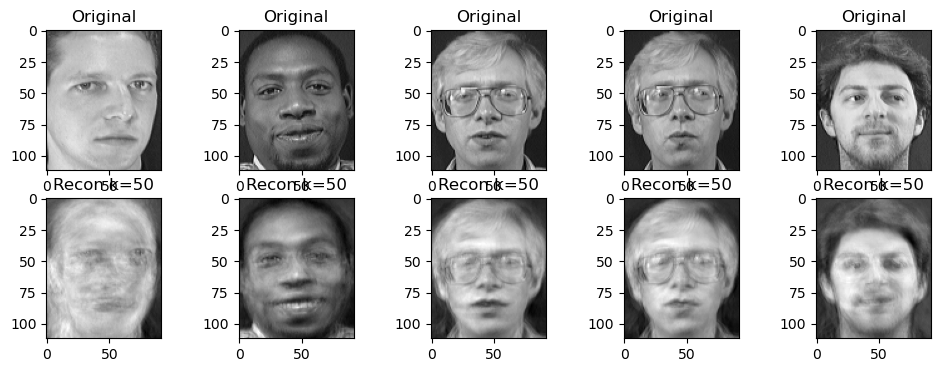

In [15]:
from sklearn.metrics import mean_squared_error
ks = [5, 10, 20, 30, 50]
rec_mse = []
sample_idxs = np.random.choice(len(X_train_std), size=min(5, len(X_train_std)), replace=False)

for k in ks:
    comps = pca(X_train_std, k)[0]
    # project train data
    coeffs = np.dot(X_train_std, comps)
    recon_std = np.dot(coeffs, comps.T)
    # unstandardize
    recon = recon_std * std_face + mean_face
    mse = mean_squared_error(X_train, recon)
    rec_mse.append(mse)
    print(f'k={k}, MSE={mse:.4f}')

plt.figure()
plt.plot(ks, rec_mse, marker='o')
plt.xlabel('k')
plt.ylabel('Reconstruction MSE')
plt.title('Reconstruction error vs k')

# show reconstructions for different k
for k in [5, 20, 50]:
    comps = pca(X_train_std, k)[0]
    coeffs = np.dot(X_train_std[sample_idxs], comps)
    recon_std = np.dot(coeffs, comps.T)
    recon = recon_std * std_face + mean_face
    plt.figure(figsize=(12,4))
    for i, idx in enumerate(sample_idxs):
        plt.subplot(2, len(sample_idxs), i+1)
        plt.imshow(X_train[idx].reshape(h, w), cmap='gray')
        plt.title('Original')
        plt.subplot(2, len(sample_idxs), len(sample_idxs)+i+1)
        plt.imshow(recon[i].reshape(h, w), cmap='gray')
        plt.title(f'Recon k={k}')

as expected, 50PCA has least error and clarity in the image incrrases as more discriminative features addition possible.

k=5, accuracy=0.8917
k=10, accuracy=0.9333
k=10, accuracy=0.9333
k=20, accuracy=0.9583
k=20, accuracy=0.9583
k=30, accuracy=0.9583
k=30, accuracy=0.9583
k=50, accuracy=0.9750
Best k: 50
k=50, accuracy=0.9750
Best k: 50
Confusion matrix shape: (40, 40)
Confusion matrix shape: (40, 40)


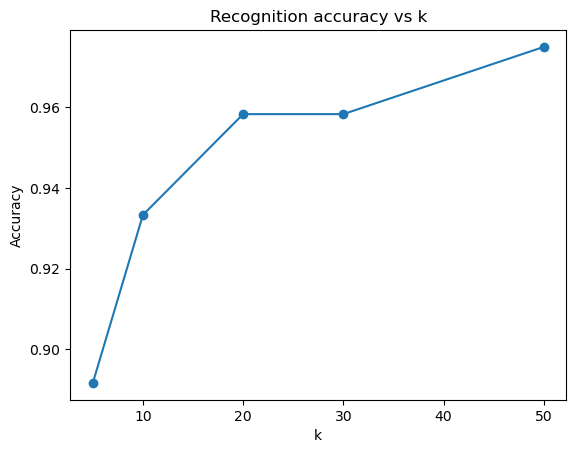

In [16]:
# recognition using 1-NN in PCA space
ks_eval = [5, 10, 20, 30, 50]
accs = []
for k in ks_eval:
    comps = pca(X_train_std, k)[0]
    X_train_proj = np.dot(X_train_std, comps)
    X_test_proj = np.dot(X_test_std, comps)
    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_train_proj, y_train)
    y_pred = knn.predict(X_test_proj)
    acc = accuracy_score(y_test, y_pred)
    accs.append(acc)
    print(f'k={k}, accuracy={acc:.4f}')

plt.figure()
plt.plot(ks_eval, accs, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Recognition accuracy vs k')

# Confusion matrix for best k
best_k = ks_eval[np.argmax(accs)]
print('Best k:', best_k)
comps = pca(X_train_std, best_k)[0]
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(np.dot(X_train_std, comps), y_train)
y_pred = knn.predict(np.dot(X_test_std, comps))
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix shape:', cm.shape)


1-NN classification in PCA space for varied k. Accuracy typically rises sharply from very low k (underfitting) to a plateau (sufficient discriminative subspace), then may stagnate or slightly dip if noisy components are added. Reported best k balances dimensionality and performance. 30 is a good value i feel.